<link rel="stylesheet" href="/site-assets/css/gemma.css">
<link rel="stylesheet" href="https://fonts.googleapis.com/css2?family=Google+Symbols:opsz,wght,FILL,GRAD@20..48,100..700,0..1,-50..200" />

##### Copyright 2026 Google LLC.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://ai.google.dev/gemma/docs/core/keras_inference"><img src="https://ai.google.dev/static/site-assets/images/docs/notebook-site-button.png" height="32" width="32" />View on ai.google.dev</a>
  </td>
    <td>
    <a target="_blank" href="https://colab.research.google.com/github/google-gemma/cookbook/blob/main/docs/core/keras_inference.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/google-gemma/cookbook/blob/main/docs/core/keras_inference.ipynb"><img src="https://www.kaggle.com/static/images/logos/kaggle-logo-transparent-300.png" height="32" width="70"/>Run in Kaggle</a>
  </td>
  <td>
    <a target="_blank" href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fgoogle-gemma%2Fcookbook%2Fmain%2Fdocs%2Fcore%2Fkeras_inference.ipynb"><img src="https://ai.google.dev/images/cloud-icon.svg" width="40" />Open in Vertex AI</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/google-gemma/cookbook/blob/main/docs/core/keras_inference.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

# Run Gemma with Keras

Generating content, summarizing, and analysing content are just some of the tasks you can accomplish with Gemma open models. This tutorial shows you how to get started running Gemma using Keras, including generating text content with text and image input. [Keras](https://keras.io/) provides implementations for running Gemma and other models using JAX, PyTorch, and TensorFlow. If you're new to Keras, you might want to read [Getting started with Keras](https://keras.io/getting_started/) before you begin.

Gemma 3 and later models support text and image input. Earlier versions of Gemma only support text input, except for some variants, including [PaliGemma](https://ai.google.dev/gemma/docs/setup).

> Note: This notebook won't run on T4 if you try with Gemma 4. Use L4 or higher GPUs.

### Install Keras packages

Install the Keras and KerasHub Python packages.

In [1]:
!pip install -q -U keras keras-hub keras-nlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.7 MB/s eta 0:00:00


### Select a backend

Keras is a high-level, multi-framework deep learning API designed for simplicity and ease of use. [Keras 3](https://keras.io/keras_3) lets you choose the backend: TensorFlow, JAX, or PyTorch. All three will work for this tutorial. For this tutorial, configure the backend for JAX as it typically provides the better performance.

In [1]:
import os

os.environ["KERAS_BACKEND"] = "jax"  # Or "tensorflow" or "torch".
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1.00"

### Import packages

Import the Keras and KerasHub packages.

In [2]:
import keras
import keras_hub

## Load model

Keras provides implementations of many popular [model architectures](https://keras.io/api/keras_nlp/models/). Download and configure a Gemma model using the `Gemma4CausalLM` class to build an end-to-end, causal language modeling implementation for Gemma 4 models. Create the model using the `from_preset()` method, as shown in the following code example:

In [3]:
gemma_lm = keras_hub.models.Gemma4CausalLM.from_preset(
    "gemma4_instruct_2b",
    dtype="bfloat16",
)

The `Gemma3CausalLM.from_preset()` method instantiates the model from a preset architecture and weights. In the code above, the string `"gemma#_xxxxxxx"` specifies a preset version and parameter size for Gemma. You can find the code strings for Gemma models in their **Model Variation** listings on [Kaggle](https://www.kaggle.com/models/keras/gemma3).


Once you have the model downloaded, Use the `summary()` function to get more info about the model:

In [4]:
gemma_lm.summary()

Preprocessor: "gemma4_causal_lm_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gemma4_tokenizer_1 (Gemma4Tokenizer)                          │                      Vocab size: 262,144 │
├───────────────────────────────────────────────────────────────┼──────────────────────────────────────────┤
│ gemma4_image_converter (Gemma4ImageConverter)                 │                       Image size: (1, 1) │
├───────────────────────────────────────────────────────────────┼──────────────────────────────────────────┤
│ gemma4_audio_converter (Gemma4AudioConverter)                 │                Audio shape: (3,000, 128) │
├───────────────────────────────────────────────────────────────┼──────────────────────────────────────────┤
│ gemma4_video_converter (Gemma4ImageConverter)                 │                       Image size: (1, 1) │
├───────────────────────────────────────────────────────────────┼──────────────────────────────────────────┤
│ gemma4_video_converter (ImageConverter)                       │                 Image size: (None, None) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "gemma4_causal_lm_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ audio_indices (InputLayer)    │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ audio_mask (InputLayer)       │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ audio_mel (InputLayer)        │ (None, None, None, 128)   │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ audio_mel_mask (InputLayer)   │ (None, None, None)        │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pixel_position_ids            │ (None, None, None, 2)     │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pixel_values (InputLayer)     │ (None, None, None, None)  │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ position_ids (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ vision_indices (InputLayer)   │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ vision_mask (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gemma4_backbone_1             │ (None, None, 1536)        │   5,104,298,467 │ audio_indices[0][0],       │
│ (Gemma4Backbone)              │                           │                 │ audio_mask[0][0],          │
│                               │                           │                 │ audio_mel[0][0],           │
│                               │                           │                 │ audio_mel_mask[0][0],      │
│                               │                           │                 │ padding_mask[0][0],        │
│                               │                           │                 │ pixel_position_ids[0][0],  │
│                               │                           │                 │ pixel_values[0][0],        │
│                               │                           │                 │ position_ids[0][0],        │
│                               │                           │                 │ token_ids[0][0],           │
│                               │                           │                 │ vision_indices[0][0],      │
│                               │                           │               

 Total params: 5,104,298,467 (10.39 GB)

 Trainable params: 5,104,186,912 (10.39 GB)

 Non-trainable params: 111,555 (435.69 KB)

The output of the summary shows the models total number of trainable parameters.
For purposes of naming the model, the embedding layer is not counted against the number of parameters.

Note: To run larger Gemma models with Google Colab, you need access to the premium GPUs available in paid plans. Alternatively, you can perform inferences using [Kaggle](https://www.kaggle.com/code) notebooks or Google Cloud projects.


## Generate text with text

Generate text with a text prompt with using `generate()` method of the Gemma model object you configured in the previous steps. The optional `max_length` argument specifies the maximum length of the generated sequence. The following code examples shows a few ways to prompt the model.

In [5]:
output = gemma_lm.generate("what is keras in 3 bullet points?", max_length=64)
print(output)

what is keras in 3 bullet points?

* **A Deep Learning Framework:** Keras is a high-level API that makes it easy to build and train deep learning models by providing a user-friendly interface.
* **User-Friendly and Fast:** It abstracts away complex mathematical details, allowing users to


You can also provide batched prompts using a list as input:

In [6]:
output = gemma_lm.generate(
    ["what is keras in 3 bullet points?",
     "The universe is"],
    max_length=64)
for item in output:
    print(item)
    print("-"*80)

what is keras in 3 bullet points?

* **A Deep Learning Framework:** Keras is a high-level API that makes it easy to build and train deep learning models by providing a user-friendly interface.
* **User-Friendly and Fast:** It abstracts away complex underlying computations, allowing users to
--------------------------------------------------------------------------------
The universe is vast and mysterious. It stretches beyond our comprehension, filled with wonders we are only beginning to uncover. From the swirling galaxies to the silent depths of the ocean, the universe whispers secrets of existence, inviting us to explore, to question, and to marvel at the sheer scale of it all.

This
--------------------------------------------------------------------------------


If you're running on JAX or TensorFlow backends, you should notice that the second `generate()` call returns an answer more quickly. This performance improvement is because each call to `generate()` for a given batch size and `max_length` is compiled with XLA. The first run is expensive, but subsequent runs are faster.

### Use a prompt template

When building more complex requests or multi-turn chat interactions use a prompt template to structure your request. The following code creates a standard template for Gemma prompts:

In [7]:
PROMPT_TEMPLATE = """<|turn>user
{question}
<turn|>
<|turn>model
"""

The following code shows how to use the template to format a simple request:

In [15]:
question = """what is keras in 3 bullet points?"""
prompt = PROMPT_TEMPLATE.format(question=question)
output = gemma_lm.generate(prompt)
print(output)


<|turn>user
what is keras in 3 bullet points?
<turn|>
<|turn>model
Here are three bullet points explaining what Keras is:

* **High-Level API for Deep Learning:** Keras is a user-friendly, high-level neural networks API that allows developers to quickly build, train, and evaluate deep learning models with minimal code.
* **Abstraction and Flexibility:** It provides a flexible and modular interface, making it easy to define complex network architectures (like CNNs or RNNs) without getting bogged down in the low-level mathematical details of frameworks like TensorFlow.
* **Backend Agnostic:** Keras acts as a consistent interface that can run on top of various powerful deep learning backends (most commonly TensorFlow, but also others), allowing users to switch frameworks easily.<turn|>


### Optional: Try a different sampler

You can control the generation strategy for model object by setting the `sampler` argument on `compile()`. By default, [`"greedy"`](https://keras.io/api/keras_nlp/samplers/greedy_sampler/#greedysampler-class) sampling will be used. As an experiment, try setting a [`"top_k"`](https://keras.io/api/keras_nlp/samplers/top_k_sampler/) strategy:

In [9]:
gemma_lm.compile(sampler="top_k")
output = gemma_lm.generate("The universe is", max_length=64)
print(output)

The universe is vast.

The stars glitter like scattered diamonds on a black velvet canvas. Nebulae swirl in vibrant hues, painting cosmic masterpieces, whispering tales of ancient creation. Galaxies spin in majestic dances, their arms reaching out into the void, a breathtaking spectacle for the eyes.

Everywhere, there, in


While the default greedy algorithm always picks the token with the largest probability, the top-K algorithm randomly picks the next token from the tokens of top K probability. You don't have to specify a sampler, and you can ignore the last code snippet if it's not helpful to your use case. If you'd like learn more about the available samplers, see [Samplers](https://keras.io/api/keras_nlp/samplers/).

## Generate text with image data

With Gemma 3 and later models, you can use images as part of a prompt to generate output. This capability allows you to use Gemma to interpret visual content or use images as data for content generation.


### Create image loader function

The following function loads an image file from a URL and tokenizes it for use in Gemma prompt:

In [10]:
import numpy as np
import PIL

def read_image(url):
    """Reads image from URL as NumPy array."""

    image_path = keras.utils.get_file(origin=url)
    image = PIL.Image.open(image_path)
    image = np.array(image)
    return image

### Load image for a prompt

Load the image and format the data so the model can process it. Use `read_image()` function defined in the previous section, as shown in the example code below:

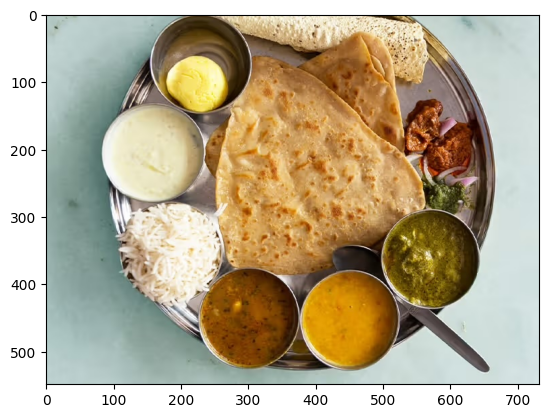

In [11]:
from matplotlib import pyplot as plt

image = read_image(
    "https://ai.google.dev/gemma/docs/images/thali-indian-plate.jpg"
)
plt.imshow(image)

<img src="/gemma/docs/images/thali-indian-plate.jpg" />

**Figure 1.** Image of Thali Indian food on a metal plate.

### Run request with an image

When prompting the Gemma 4 model with image content, you use a specific string sequence, `<|image|>`, within your prompt to include the image as part of the prompt. Use a prompt template, such as the `PROMPT_TEMPLATE` string defined previously, to format your request as shown in the following prompt code:

In [19]:
question = """Which cuisine is this: <|image|>?
Identify the food items present. Which macros is the meal
high and low on? Keep your answer short.
"""

output = gemma_lm.generate(
    {
        "images": image,
        "prompts": PROMPT_TEMPLATE.format(question=question),
    },
)
print(output)

<|turn>user
Which cuisine is this: <|image>?
Identify the food items present. Which macros is the meal
high and low on? Keep your answer short.

<turn|>
<|turn>model
Based on the image, here is the analysis:

**Cuisine:**
The food items strongly suggest **Indian cuisine** or South Asian cuisine.

**Food Items Present:**
*   **Flatbread:** Likely Roti, Chapati, or Naan.
*   **Rice:** Plain steamed white rice.
*   **Dips/Condiments:** A white sauce (like raita or yogurt-based sauce), and several curries/sauces (one appears to be a lentil/vegetable curry, another a tomato/onion-based curry, and others green/spicy sauces).

**Macros Analysis (General Estimate):**
*   **High on:** Carbohydrates (from rice and flatbread) and Fats (depending on how the flatbread was cooked and the richness of the sauces/curries).
*   **Low on:** Protein (unless a significant amount of meat/legumes is present in the unseen curries) and Fiber (unless the curries are vegetable-heavy).<turn|>


If you are using a smaller GPU, and encountering out of memory (OOM) errors, you can set `max_images_per_prompt` and `sequence_length` to smaller values. The following code shows how to reduce sequence length to 768.

In [13]:
gemma_lm.preprocessor.max_images_per_prompt = 2
gemma_lm.preprocessor.sequence_length = 768

### Run requests with multiple images

When using more than one image in a prompt, use multiple `<|image|>` tokens for each provided image, as shown in the following example:

In [18]:
photo_a = read_image("https://raw.githubusercontent.com/google-gemma/cookbook/refs/heads/main/apps/sample-data/GoldenGate.png")
photo_b = read_image("https://raw.githubusercontent.com/google-gemma/cookbook/refs/heads/main/apps/sample-data/surprise.png")

question = """I have two images:

Photo A: <|image|>
Photo B: <|image|>

Tell me a bit about these.
Keep it short.
"""

output = gemma_lm.generate(
    {
        "images": [photo_a, photo_b],
        "prompts": PROMPT_TEMPLATE.format(question=question),
    },
)
print(output)

<|turn>user
I have two images:

Photo A: <|image>
Photo B: <|image>

Tell me a bit about these.
Keep it short.

<turn|>
<|turn>model
Photo A is a picture of the **Golden Gate Bridge** in San Francisco, California, with water and hills in the background.

Photo B is a close-up portrait of a **cat** with black and white markings and striking green eyes.<turn|>


## What's next

In this tutorial, you learned how to generate text using Keras and Gemma. Here are a few suggestions for what to learn next:

* Learn how to [finetune a Gemma model](https://ai.google.dev/gemma/docs/core/lora_tuning).
* Learn how to perform [distributed fine-tuning and inference on a Gemma model](https://ai.google.dev/gemma/docs/core/distributed_tuning).
* Learn about [Gemma integration with Vertex AI](https://ai.google.dev/gemma/docs/integrations/vertex)
* Learn how to [use Gemma models with Vertex AI](https://cloud.google.com/vertex-ai/docs/generative-ai/open-models/use-gemma).